In [ ]:
import gym
from torch import nn
import torch.optim as optim
import torch

In [ ]:
env = gym.make('CartPole-v1')

/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self, state_dim, action_dim):
    super(NeuralNetwork, self).__init__()
    self.hidden1 = nn.Linear(state_dim, 128)
    self.hidden2 = nn.Linear(128, action_dim)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=-1)
  def forward(self, state):
    x = self.hidden1(state)
    x = self.relu(x)
    x = self.hidden2(x)
    x = self.softmax(x)
    return x

In [ ]:
policy = NeuralNetwork(state_dim, action_dim)

In [ ]:
optimizer = optim.Adam(policy.parameters())

In [ ]:
def select_action(state):
  state = torch.from_numpy(state).float().unsqueeze(0)
  action_probs = policy(state)
  action = torch.multinomial(action_probs, num_samples=1)
  log_prob = torch.log(action_probs[0, action])
  return action.item(), log_prob

In [ ]:
def compute_rewards(rewards, gamma=0.99):
  returns = []
  R = 0
  for r in rewards[::-1]:
    R = r + gamma * R
    returns.insert(0,R)
  return returns

In [ ]:
num_episodes = 1000
total_rewards = []
for episode in range(num_episodes):
  state = env.reset()
  rewards = []
  log_probs = []
  for t in range(1000):
    action, log_prob = select_action(state)
    state, reward, done, _ = env.step(action)
    rewards.append(reward)
    log_probs.append(log_prob)
    if done:
      break

  total_rewards.append(sum(rewards))
  returns = compute_rewards(rewards)
  returns = torch.tensor(returns)
  policy_loss = []
  for log_prob, R in zip(log_probs, returns):
    policy_loss.append(-log_prob * R)
  policy_loss = torch.stack(policy_loss).sum()

  optimizer.zero_grad()
  policy_loss.backward()
  optimizer.step()

  if episode % 100 == 0:
    print("Episode: {}, Last length: {}".format(episode, t))

Episode: 0, Last length: 16
Episode: 100, Last length: 28
Episode: 200, Last length: 35
Episode: 300, Last length: 171
Episode: 400, Last length: 100
Episode: 500, Last length: 219
Episode: 600, Last length: 459
Episode: 700, Last length: 499


KeyboardInterrupt: ignored

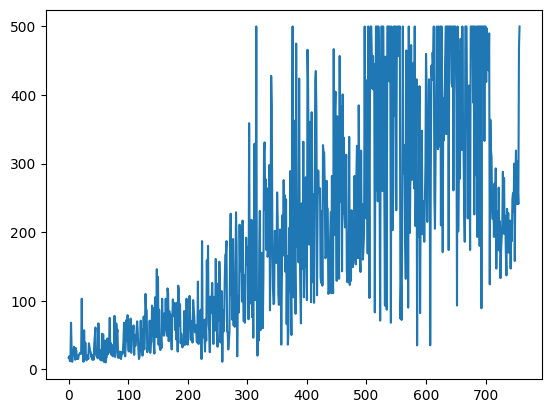

In [ ]:
import matplotlib.pyplot as plt
plt.plot(total_rewards)
plt.show()

In [ ]:
!pip3 install gym pyvirtualdisplay


In [ ]:
!apt-get install -y xvfb python-opengl > /dev/null 2>&1

In [ ]:
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

In [ ]:
display = Display(visible = 0, size = (400, 300))
display.start()

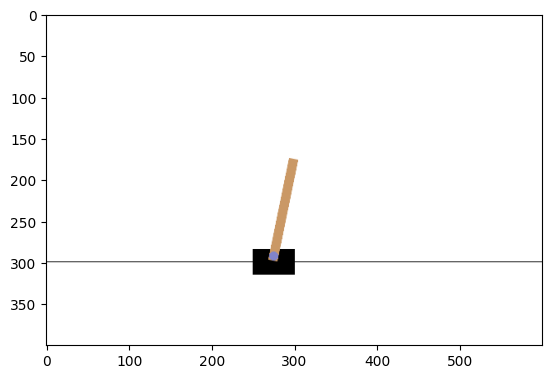

In [ ]:
state = env.reset()
img = plt.imshow(env.render("rgb_array"))
for i in range(1000):
  img.set_data(env.render("rgb_array"))
  ipythondisplay.display(plt.gcf())
  ipythondisplay.clear_output(wait=True)
  action = env.action_space.sample()
  state, reward, done, _ = env.step(action)
  if done:
    break